## การแก้ไข Batch
File นี้เป็นตัวอย่างที่จะแสดงให้เห็นถึงผลกระทบของการปรับ batch size

ซึ่งผลกระทบหลักๆของการปรับ batch คือความสามารถในการปรับตัว(เรียนรู้)ของโมเดล เดี๋ยวเราจะได้มาดูกันว่าผลกระทบระหว่าง batch ที่ต่ำเกินไปหรือสูงเกินไปนั้นเป็นอย่างไร


In [2]:
# TensorFlow and tf.keras
import matplotlib.pyplot as plt

# Helper libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(42)  # ทำให้การทดลองทำซ้ำได้ใกล้เคียงเดิม
print(tf.__version__)
print(keras.__version__)
print(tf.config.list_physical_devices())  # แสดง processor ที่สามารถรัน tensorflow ได้

2.21.0
3.15.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


dtype('float32')

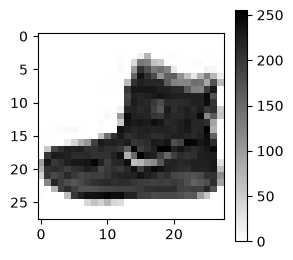

In [4]:
fashion_mnist = keras.datasets.fashion_mnist  # get the dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# spliting data set into train & test
plt.figure(figsize=(3, 3))
plt.imshow(train_images[0], cmap=plt.cm.binary)
# plt.imshow(train_images[0], cmap=plt.cm.gray_r)
plt.colorbar()
plt.grid(False)

# normalisation
train_images = train_images / 255.0
test_images = test_images / 255.0

print(type(train_images))
print(type(test_images))

train_images = train_images.astype(np.float32)
test_images = test_images.astype(np.float32)


train_images.dtype

## สร้างโมเดลในรูปแบบ sequential 

<font color="blue">__ตอนนี้ batch_size=4 อาจจะใช้เวลาฝึกประมาณ 5-10 นาที__</font> กดรันแล้วก็ไปอ่านแบบฝึกหัดด้านล่างกันต่อได้เลยนะครับ
(ตอนแรกจะให้ใช้ batch_size=1 แต่มันนานเกินไป)

In [5]:
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()
history = model.fit(train_images,train_labels,batch_size=4, epochs=10)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8158 - loss: 0.5341
Epoch 2/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.8439 - loss: 0.4547
Epoch 3/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8493 - loss: 0.4394
Epoch 4/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8523 - loss: 0.4309
Epoch 5/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step - accuracy: 0.8542 - loss: 0.4252
Epoch 6/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8551 - loss: 0.4210
Epoch 7/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8564 - loss: 0.4178
Epoch 8/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.8573 - loss: 0.4151
Epoch 9/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8579 - loss: 0.4129
Epoch 10/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.8586 - loss: 0.4110


In [6]:
print(train_images.shape)
print(train_images.shape[0])

(60000, 28, 28)
60000


## History จากการ train โมเดล
เราสามารถดึง history หรือประวัติการฝึกแต่ละรอบออกมาดูได้ ซึ่งมันจะถูกเก็บอยู่ในรูปแบบของ dictionary โดยจะมี key เป็น `'accuracy', 'loss', 'val_accuracy', 'val_loss'`
1. accuracy คือ ความแม่นยำต่อ training data ในแต่ละ epoch
2. loss คือ อัตราสูญเสียหรือผิดพลาดต่อ(error) training data ในแต่ละ epoch

แต่ถ้าใส่ validation data เข้าไปด้วยจะมี key เพิ่มมาอีก 2 ตัวคือ:
1. val_accuracy คือ ความแม่นยำต่อ validation data ในแต่ละ epoch
2. loss คือ อัตราสูญเสียหรือผิดพลาดต่อ validation data ในแต่ละ epoch

(แต่ตอนนี้ยังไม่ได้ใส่ validation)

In [15]:
print(history.history.keys())
# print(history.history['loss'])
key = 'accuracy' # <---------- สามารถเปลี่ยนไปใช้ key อื่นก็ได้
for i, value in enumerate(history.history[key]):
    print(f"epoch {i+1}: {value}")

print("====================")

key = 'loss' # <---------- สามารถเปลี่ยนไปใช้ key อื่นก็ได้
for i, value in enumerate(history.history[key]):
    print(f"epoch {i+1}: {value}")

dict_keys(['accuracy', 'loss'])
epoch 1: 0.8158166408538818
epoch 2: 0.8438833355903625
epoch 3: 0.8493333458900452
epoch 4: 0.852316677570343
epoch 5: 0.854200005531311
epoch 6: 0.8551499843597412
epoch 7: 0.8563833236694336
epoch 8: 0.8572666645050049
epoch 9: 0.8579000234603882
epoch 10: 0.8585666418075562
epoch 1: 0.5340909361839294
epoch 2: 0.4546847641468048
epoch 3: 0.4393535852432251
epoch 4: 0.43088775873184204
epoch 5: 0.42521125078201294
epoch 6: 0.4210365116596222
epoch 7: 0.41778042912483215
epoch 8: 0.4151363968849182
epoch 9: 0.4129233658313751
epoch 10: 0.41103070974349976


## <font color="red">แบบฝึกหัดที่ 1</font>
1. หลังจากรันด้วย `batch_size=4` ให้บันทึกเวลาที่แสดงใน Keras progress bar ของแต่ละ epoch แล้วรวมเวลา 10 epoch
```python
Epoch 1/10
15000/15000 ━━━━━━━━━━━━━━━━━━━━ **64s** 1ms/step - accuracy: 0.7865 - loss: 0.6320
```
   > จาก output ด้านบนแปลว่ารอบนี้ใช้ไปทั้งหมด 64 วินาที

2. สรุป **training accuracy** และ **training loss** ใน epoch สุดท้ายมีค่าเท่าไหร่ 

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 1

Epoch 1/10 ━━━━━━━━━━━━━━━━━━━━ 23s

Epoch 2/10 ━━━━━━━━━━━━━━━━━━━━ 22s

Epoch 3/10 ━━━━━━━━━━━━━━━━━━━━ 23s

Epoch 4/10 ━━━━━━━━━━━━━━━━━━━━ 23s 

Epoch 5/10  ━━━━━━━━━━━━━━━━━━━━ 21s 

Epoch 6/10 ━━━━━━━━━━━━━━━━━━━━ 23s 

Epoch 7/10 ━━━━━━━━━━━━━━━━━━━━ 23s 

Epoch 8/10 ━━━━━━━━━━━━━━━━━━━━ 22s 

Epoch 9/10 ━━━━━━━━━━━━━━━━━━━━ 24s 

Epoch 10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 

+ Overall : 226s

ข้อที่ 2
> epoch 10: acc = 0.8586 , loss = 0.4110

## <font color="red">แบบฝึกหัดที่ 2</font>
1. จงปรับโค้ดที่ให้มาให้ใช้ `batch_size` เป็น 16 แล้วทำการรัน
2. บันทึกเวลาที่แสดงใน Keras progress bar ของแต่ละ epoch แล้วรวมเวลา 10 epoch
3. เลข 3750 นั้นมาจากอะไร? แสดงสมการการคำนวณให้ด้วย
```python
Epoch 1/10
**3750/3750** ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7552 - loss: 0.7182
```
4. สรุป **training accuracy** และ **training loss** ใน epoch สุดท้ายมีค่าเท่าไหร่ 

In [8]:
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    # keras.Input(shape=(28,28)),
    keras.layers.Flatten(input_shape = (28, 28)),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()
history = model.fit(train_images,train_labels,batch_size=16, epochs=10)

/home/sothea/miniconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8084 - loss: 0.5624
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8459 - loss: 0.4497
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8529 - loss: 0.4284
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8564 - loss: 0.4170
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8588 - loss: 0.4096
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8600 - loss: 0.4042
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8612 - loss: 0.3999
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8623 - loss: 0.3965
Epoch 9/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8633 - loss: 0.3936
Epoch 10/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8640 - loss: 0.3912


<font color="blue">พื้นที่สำหรับตอบคำถาม</font>


ข้อที่ 2
> epoch 1: 6s
> 
> epoch 2: 7s
> 
> epoch 3: 6s
> 
> epoch 4: 10s
> 
> epoch 5: 6s
> 
> epoch 6: 7s
> 
> epoch 7: 6s
> 
> epoch 8: 6s
> 
> epoch 9: 6s
> 
> epoch 10: 6s
> 
+ overall : 66s

ข้อที่ 3
> 3750 get from train_images.shape[0] / batch_size 

ข้อที่ 4
> epoch 10: acc = 0.8640 , loss = 0.3912

## <font color="red">แบบฝึกหัดที่ 3</font>
ให้รันแต่ละ cell ด้านล่างแยกกัน โดยแต่ละ cell จะสร้างและ compile โมเดลใหม่ เพื่อให้เปรียบเทียบผลได้อย่างยุติธรรม สำหรับทุกข้อ ให้บันทึกเวลาจาก Keras progress bar ของแต่ละ epoch แล้วรวมเวลา 10 epoch พร้อมบันทึก **training accuracy** และ **training loss** ใน epoch สุดท้าย

1. fit โมเดลด้วย batch_size 32
2. fit โมเดลด้วย batch_size 64
3. fit โมเดลด้วย batch_size 128
4. fit โมเดลด้วย batch_size 256 (หากเครื่องรันไม่ได้ ให้บันทึก `N/A (VRAM ไม่พอ)` ในตาราง)

In [9]:
# ข้อ 1: batch_size=32
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer=keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, batch_size=32, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7995 - loss: 0.5976
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8422 - loss: 0.4606
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8505 - loss: 0.4348
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8549 - loss: 0.4212
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8576 - loss: 0.4124
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8594 - loss: 0.4060
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8608 - loss: 0.4011
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8621 - loss: 0.3972
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8629 - loss: 0.3939
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8636 - loss: 0.3911


In [10]:
# ข้อ 2: batch_size=64
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer=keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7819 - loss: 0.6545
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8363 - loss: 0.4828
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8461 - loss: 0.4507
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8511 - loss: 0.4338
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8548 - loss: 0.4229
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8570 - loss: 0.4151
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.4092
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.4044
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8614 - loss: 0.4005
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8625 - loss: 0.3972


In [11]:
# ข้อ 3: batch_size=128
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer=keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, batch_size=128, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7566 - loss: 0.7402
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8285 - loss: 0.5160
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8402 - loss: 0.4748
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8465 - loss: 0.4531
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8504 - loss: 0.4391
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8531 - loss: 0.4291
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.4215
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8578 - loss: 0.4155
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8595 - loss: 0.4105
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8606 - loss: 0.4064


In [12]:
# ข้อ 4: batch_size=256
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer=keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, batch_size=256, epochs=10)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7237 - loss: 0.8596
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8143 - loss: 0.5643
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.5099
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8385 - loss: 0.4818
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8443 - loss: 0.4637
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8480 - loss: 0.4508
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8507 - loss: 0.4409
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8530 - loss: 0.4331
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8547 - loss: 0.4267
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8561 - loss: 0.4213


<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 1
> Epoch 1/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 

>Epoch 2/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 

>Epoch 3/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 

>Epoch 4/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 

>Epoch 5/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 

>Epoch 6/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 

>Epoch 7/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 

>Epoch 8/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 

>Epoch 9/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 

>Epoch 10/10 : 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s - accuracy: 0.8636 - loss: 0.3911

+ Overall Time: 30s

ข้อที่ 2
> Epoch 1/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 

>Epoch 2/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 3/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 4/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 5/10 :
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 

>Epoch 6/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 7/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 8/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 9/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 

>Epoch 10/10 : 
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s  - accuracy: 0.8625 - loss: 0.3972

+ Overall Time: 14s


ข้อที่ 3
> Epoch 1/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 2/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 3/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 4/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 5/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 6/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 7/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 8/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 9/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 10/10 : 
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s  - accuracy: 0.8606 - loss: 0.4064
>
+ Overall Time: 10s

ข้อที่ 4
> Epoch 1/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 2/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 

>Epoch 3/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 

>Epoch 4/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 

>Epoch 5/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 

>Epoch 6/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 

>Epoch 7/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 

>Epoch 8/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 

>Epoch 9/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 

>Epoch 10/10 : 
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s - accuracy: 0.8561 - loss: 0.4213
>
+ Overall Time: 2s


## <font color="red">แบบฝึกหัดที่ 4</font>
1. จงเติมตารางสรุปผลด้านล่างให้สมบูรณ์

| batch size | เวลารวม 10 epoch (วินาที) | training accuracy (epoch สุดท้าย) | training loss (epoch สุดท้าย) |
|---:|---:|---:|---:|
| 4        |    226     |     0.8586     |     0.4110     |
| 16       |     66     |     0.8640     |     0.3912     |
| 32       |     30     |     0.8636     |     0.3911     |
| 64       |     14     |     0.8625     |     0.3972     |
| 128      |     10     |     0.8606     |     0.4064     |
| 256      |      2     |     0.8561     |     0.4213     |

2. ถ้าเป็นนศ.เป็นผู้พัฒนา AI นี้ และต้องสร้างโมเดลขึ้นมาด้วยตัวเอง
   1. หากอยู่ใน**ขั้นตอนทดลอง**ที่ต้องมีการปรับ setting ของโมเดลและเทรนบ่อยๆ นศ.คิดว่า batch ที่เท่าไหร่เหมาะสมที่สุด?
   2. หากอยู่ใน**ขั้นตอน train รอบสุดท้าย** นศ.คิดว่า batch size ใดเหมาะสมที่สุด โดยพิจารณาเวลา, VRAM และผลลัพธ์ที่ได้?
   > ข้อนี้ไม่มีถูกไม่มีผิด ให้พิจารณาความสมดุลระหว่างเวลา train, VRAM และผลลัพธ์ที่ได้จากการทดลอง

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 2 A
> I think batch_size = 16 because it has the high accuray and the loss and time are bettor compare to others model.

ข้อที่ 2 B
> I will choose batch_size = 32 because it has the lowest loss and its accuray almost the same as batch_size 16 and time used less than it too.

## บทสรุป

จุดประสงค์ของแบบฝึกหัดนี้คือให้เห็นผลของ batch size ต่อเวลาในการ train, การใช้ VRAM, ความถี่ในการ update weights และความเสถียรของ gradient

- หากปรับ batch ให้น้อยมากๆ
    - โมเดล update weights บ่อย และใช้ VRAM น้อย แต่ gradient มีความผันผวนมากกว่าและอาจใช้เวลาฝึกนาน
    - เหตุการณ์ที่เหมาะกับการใช้ batch เล็กๆคือการที่มีโมเดลเรียนรู้แบบ online หรือเรียนรู้แบบ real-time ที่รับข้อมูลมาเป็น streaming data
- หากปรับ batch สูงมากๆ
    - โมเดล update weights ไม่บ่อย แต่ gradient มีความเสถียรมากขึ้น เพราะคำนวณจากข้อมูลจำนวนมาก
    - มีความเสี่ยงที่ VRAM จะไม่พอต่อการโหลดข้อมูลในแต่ละ batch
- หากปรับ batch ไม่น้อยหรือสูงมากเกินไป (balanced)
    - เป็นจุดสมดุลระหว่างความเร็วในการ train, การใช้ VRAM และความเสถียรของ gradient
    - โดยทั่วไปจึงนิยมใช้ mini-batch เช่น 32, 64 หรือ 128 ตามข้อจำกัดของเครื่องและผลการทดลอง

[]
